# Quick Start (Square Bin)

## Introduction of raw data

#### GEM and GEF

There are two types of Stereo-seq data, GEM and GEF. The format of original expression matrix of GEM file is as follows: x, y are the spatial position of the gene in tissue section, and MIDCount is the number of gene expression. ExonCount is the number of exons expression only in GEM file, which is generated by `spatial_RNA_visualization_v5` in SAP or SAW (version >= 5.1.3).

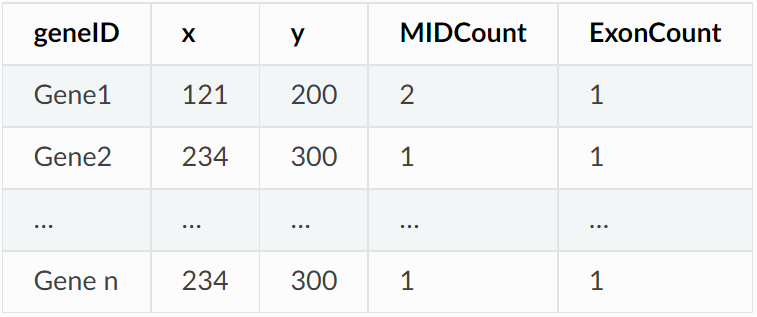

More information of GEF file is in the [format documentation](https://www.processon.com/view/link/610cc49c7d9c087bbd1ab7ab#map). Usually, we recommend using GEF format of which reading speed is much faster than GEM.

#### Bin size

The resolution of Stereo-seq technology is up to nanometer level, where nanopore radius of bin1 is 250 nm.

Generally, `bin_size` parameter is set to combine the nanopores within a certain range into a `bin unit`. For instance, the side length of the bin unit is approximately 10 or 14 microns when `bin_size` is set to 20, according to different center-to-center distances, like 500 nm or 715 nm.

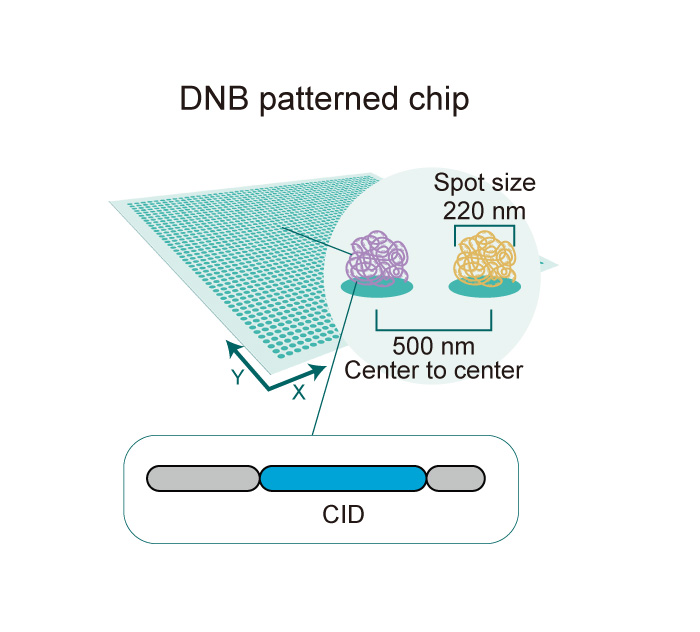

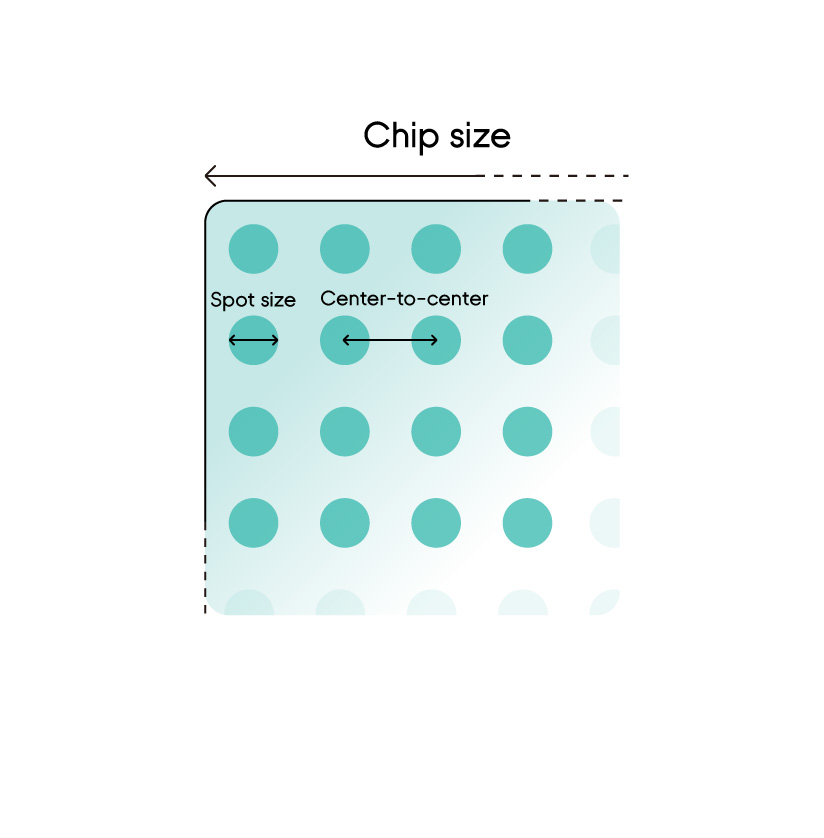

After the combination according to a certain **bin_size**, we will uniformly generate data into the format of StereoExpData.

#### Performance

At the end of this part, we display the running [performance](https://stereopy.readthedocs.io/en/latest/Tutorials/Performance.html) of different bin_sizes to those who are handling mass data and more concerned about computational performance. Welcome to come back here after having finished this example. Also, similar performing tests come up elsewhere in Stereopy. 

In [ ]:
# configure parameters
gef_path='/data/input/Files/yangdong/M.truncatula/SAW/WT202604020036551/result/Y00710F6/outs/feature_expression/Y00710F6.tissue.gef'
bin_type='bins'
bin_size=50

## Reading data

Firstly, download our [example data](http://upload.dcs.cloud:8090/share/bb6fab82-2c16-46b2-a95e-6931338f31bf) and import Stereopy.

In [1]:
import stereo as st
import warnings
warnings.filterwarnings('ignore')

Get the version information of Stereopy.

In [3]:
st.__version__

'1.6.0'

Get attributes of the GEF file.

In [ ]:
# data_path = '/data/input/Files/yangdong/M.truncatula/SAW/WT202604020036551/result/Y00710F6/outs/feature_expression/Y00710F6.tissue.gef'

st.io.read_gef_info(gef_path)

[2026-04-26 16:03:27][Stereo][2786][MainThread][140660780795712][reader][1517][INFO]: This is GEF file which contains traditional bin infomation.
[2026-04-26 16:03:27][Stereo][2786][MainThread][140660780795712][reader][1518][INFO]: bin_type: bins
[2026-04-26 16:03:27][Stereo][2786][MainThread][140660780795712][reader][1521][INFO]: Bin size list: ['bin1', 'bin10', 'bin100', 'bin150', 'bin20', 'bin200', 'bin5', 'bin50']
[2026-04-26 16:03:27][Stereo][2786][MainThread][140660780795712][reader][1527][INFO]: Resolution: 500
[2026-04-26 16:03:27][Stereo][2786][MainThread][140660780795712][reader][1530][INFO]: Gene count: 103865
[2026-04-26 16:03:27][Stereo][2786][MainThread][140660780795712][reader][1539][INFO]: offsetX: 0
[2026-04-26 16:03:27][Stereo][2786][MainThread][140660780795712][reader][1542][INFO]: offsetY: 0
[2026-04-26 16:03:27][Stereo][2786][MainThread][140660780795712][reader][1545][INFO]: Width: 23519
[2026-04-26 16:03:27][Stereo][2786][MainThread][140660780795712][reader][1548]

{'bin_list': ['bin1',
  'bin10',
  'bin100',
  'bin150',
  'bin20',
  'bin200',
  'bin5',
  'bin50'],
 'resolution': 500,
 'gene_count': 103865,
 'offsetX': 0,
 'offsetY': 0,
 'width': 23519,
 'height': 23519,
 'maxExp': 99}

Load data to generate a StereoExpData object.

In [ ]:
data = st.io.read_gef(file_path=data_path, bin_type=bin_type, bin_size=bin_size)

# simply type the varibale to get related information
data

[2026-04-26 16:03:32][Stereo][2786][MainThread][140660780795712][reader][1339][INFO]: read_gef begin ...


2026-04-26 16:03:32 [INFO   ] input file:/data/input/Files/yangdong/M.truncatula/SAW/WT202604020036551/result/Y00710F6/outs/feature_expression/Y00710F6.tissue.gef specify block size:50


[2026-04-26 16:03:37][Stereo][2786][MainThread][140660780795712][reader][1488][INFO]: the matrix has 45728 cells, and 103865 genes.
[2026-04-26 16:03:37][Stereo][2786][MainThread][140660780795712][reader][1489][INFO]: read_gef end.


StereoExpData object with n_cells X n_genes = 45728 X 103865
bin_type: bins
bin_size: 50
offset_x = 0
offset_y = 0
cells: ['cell_name']
genes: ['gene_name', 'real_gene_name']
cells_matrix = ['spatial']
Layers with keys: 
tl.result: []

##  Preprocessing

Data preprocessing includes three modules: quality control, filtering and normalization.

#### Quality Control

This module calculates the quality distribution of original data, using three indicators:

    total_counts - the total counts per cell;

    n_genes_by_counts - the number of genes expressed in count maxtrix;

    pct_countss_mt - the percentage of counts in mitochondrial genes.

In [6]:
data.tl.cal_qc()

[2026-04-26 16:03:39][Stereo][2786][MainThread][140660780795712][st_pipeline][41][INFO]: start to run cal_qc...
[2026-04-26 16:03:40][Stereo][2786][MainThread][140660780795712][st_pipeline][44][INFO]: cal_qc end, consume time 0.8466s.


Show the violin figure of QC distribution.

Column
    [0] Markdown(str)
    [1] Row
        [0] TextInput(name='file name', placeholder='Enter a file name...', width=200)
        [1] Select(name='file format', options=['png', 'pdf'], value='png', width=60)
        [2] IntInput(name='dpi', placeholder='Enter the dip...', start=0, value=100, width=200)
    [2] Row
        [0] Button(button_type='primary', name='export', width=100)
        [1] StaticText(width=800)

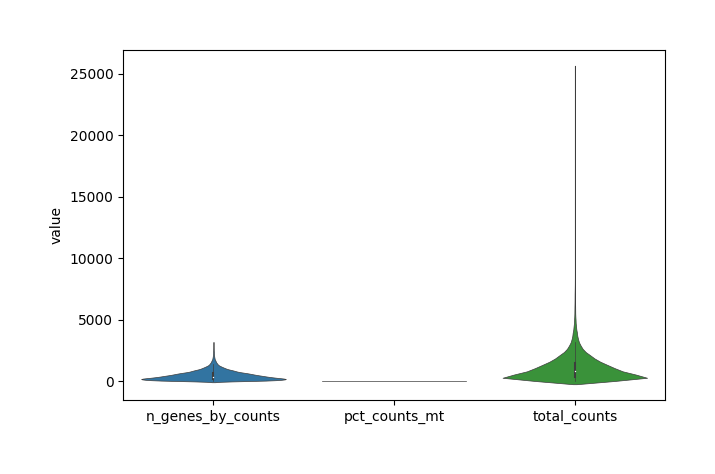

In [7]:
data.plt.violin()

<div class="alert alert-info">

**Note**

Just input your file name and click the download button to save visualization result, or set parameter in plot functions.

</div>

Show the spatial scatter figure of QC distribution.

Column
    [0] Markdown(str)
    [1] Row
        [0] TextInput(name='file name', placeholder='Enter a file name...', width=200)
        [1] Select(name='file format', options=['png', 'pdf'], value='png', width=60)
        [2] IntInput(name='dpi', placeholder='Enter the dip...', start=0, value=100, width=200)
    [2] Row
        [0] Button(button_type='primary', name='export', width=100)
        [1] StaticText(width=800)

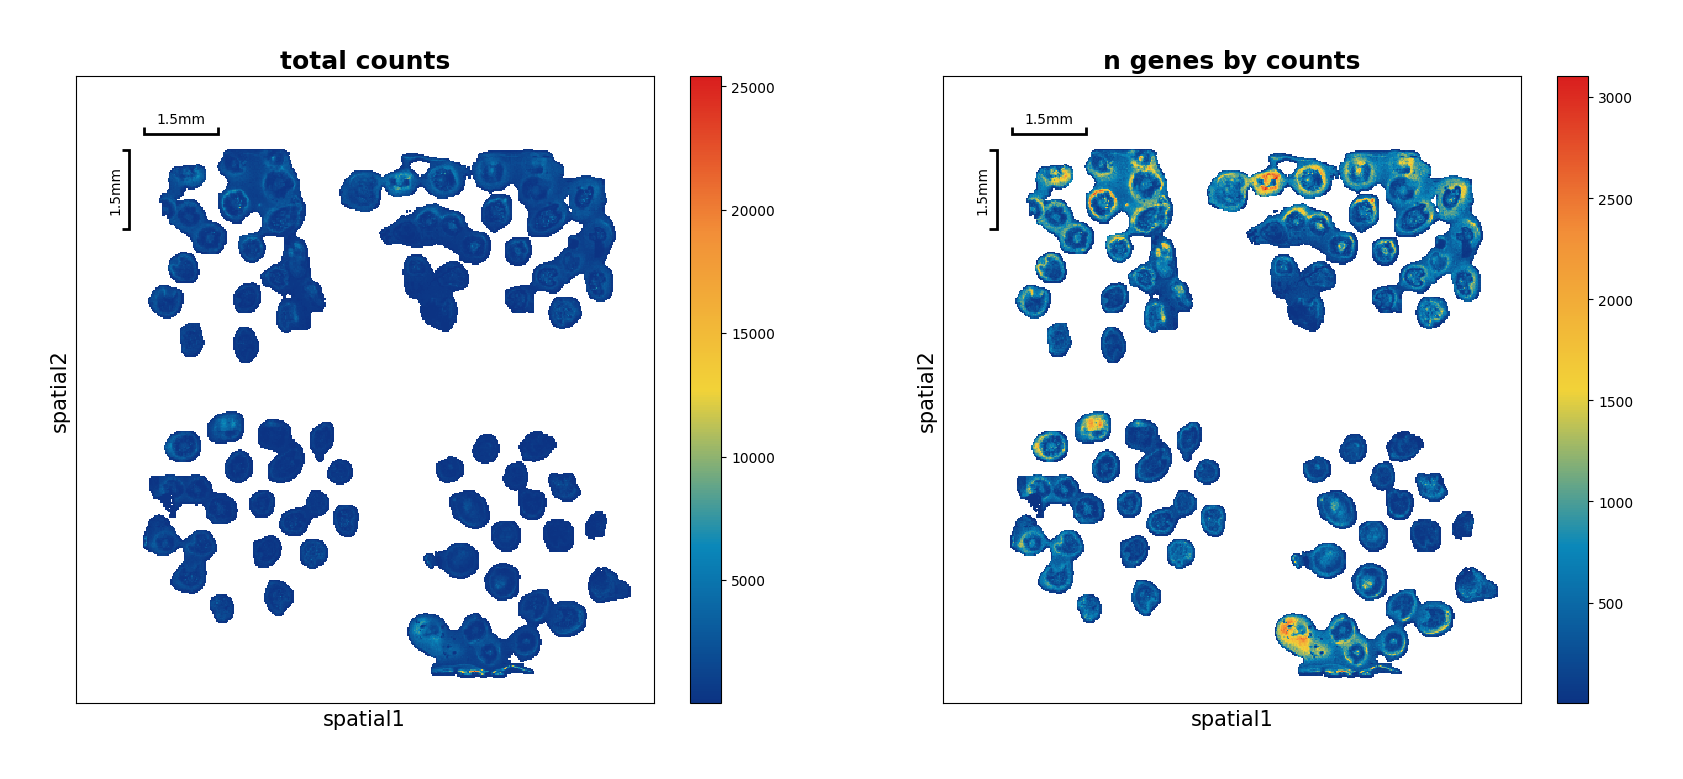

In [8]:
data.plt.spatial_scatter()

#### Filtering 

Three basic methods are provided to filter data maxtrix:

`data.tl.filter_cells`,
`data.tl.filter_genes`,
`data.tl.filter_coordinates`.

Literally, you could filter data on three optional levels: cell, gene and coordinate where a `bin unit` could be treated as a made-up cell provisionally.

We filter `bin units` (**bin_size** is set to 50 at the beginning of our example) based on quality control indicators which have been calculated in QC part. Beforehand, observe the distribution of cells according to scatter plots.

Column
    [0] Markdown(str)
    [1] Row
        [0] TextInput(name='file name', placeholder='Enter a file name...', width=200)
        [1] Select(name='file format', options=['png', 'pdf'], value='png', width=60)
        [2] IntInput(name='dpi', placeholder='Enter the dip...', start=0, value=100, width=200)
    [2] Row
        [0] Button(button_type='primary', name='export', width=100)
        [1] StaticText(width=800)

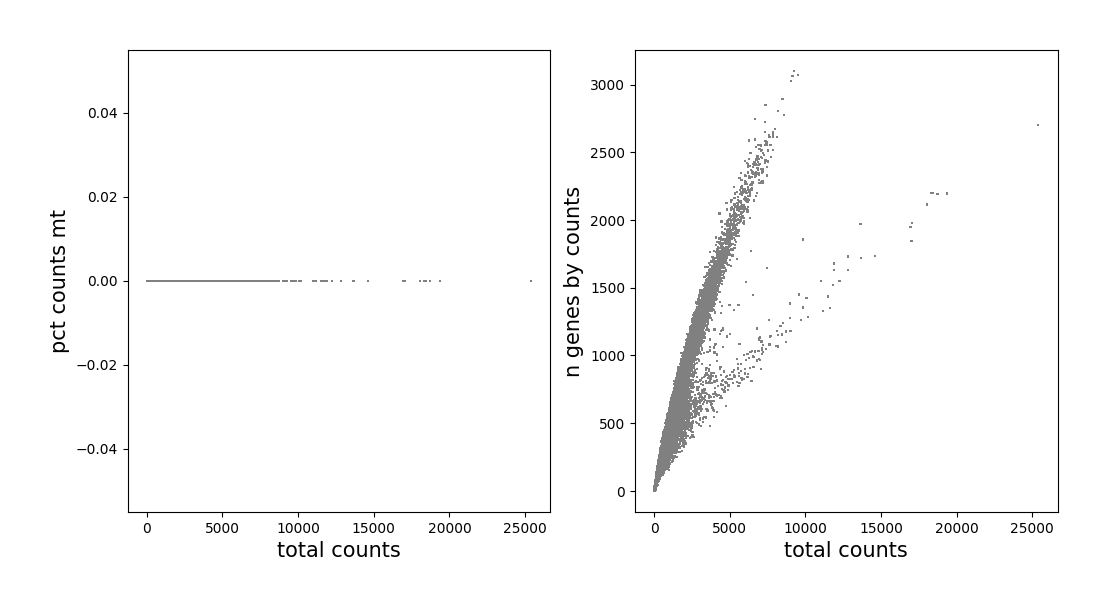

In [9]:
data.plt.genes_count()

Remove cells that have too many mitochondrial genes expressed, as well as cells without enough counts and genes expressed.

In [10]:
# data.tl.filter_cells(
#         min_counts=20, 
#         min_genes=3, 
#         pct_counts_mt=5, 
#         inplace=True
#         )
# data

see marker genes
| 基因名 | LOC ID | Medtr ID | MtrunA17 ID | Chr ID |
|:---|:---|:---|:---|:---|
| MtYABBY2a | LOC11416031 | Medtr2g087740 | MtrunA17Chr2g0322221 | Chr2012264 |
| MtYABBY2b | LOC11446936 | Medtr4g050300 | MtrunA17Chr4g0025361 | Chr4023437 |
| MtYABBY5 | LOC11439230 | Medtr4g114730 | MtrunA17Chr4g0063931 | Chr4027514 |
| MtFIL | LOC11410996 | Medtr4g101660 | MtrunA17Chr4g0056521 | Chr4026732 |
| MtYABBY3 | LOC25491643 | Medtr4g025900 | MtrunA17Chr4g0011841 | Chr4022018 |
| MtYINO | LOC11405863 | Medtr5g034030 | MtrunA17Chr5g0413381 | Chr5031033 |
| MtCRC7 | LOC11432078 | Medtr5g046230 | MtrunA17Chr5g0419871 | Chr5031730 |

Column
    [0] Markdown(str)
    [1] Row
        [0] TextInput(name='file name', placeholder='Enter a file name...', width=200)
        [1] Select(name='file format', options=['png', 'pdf'], value='png', width=60)
        [2] IntInput(name='dpi', placeholder='Enter the dip...', start=0, value=100, width=200)
    [2] Row
        [0] Button(button_type='primary', name='export', width=100)
        [1] StaticText(width=800)

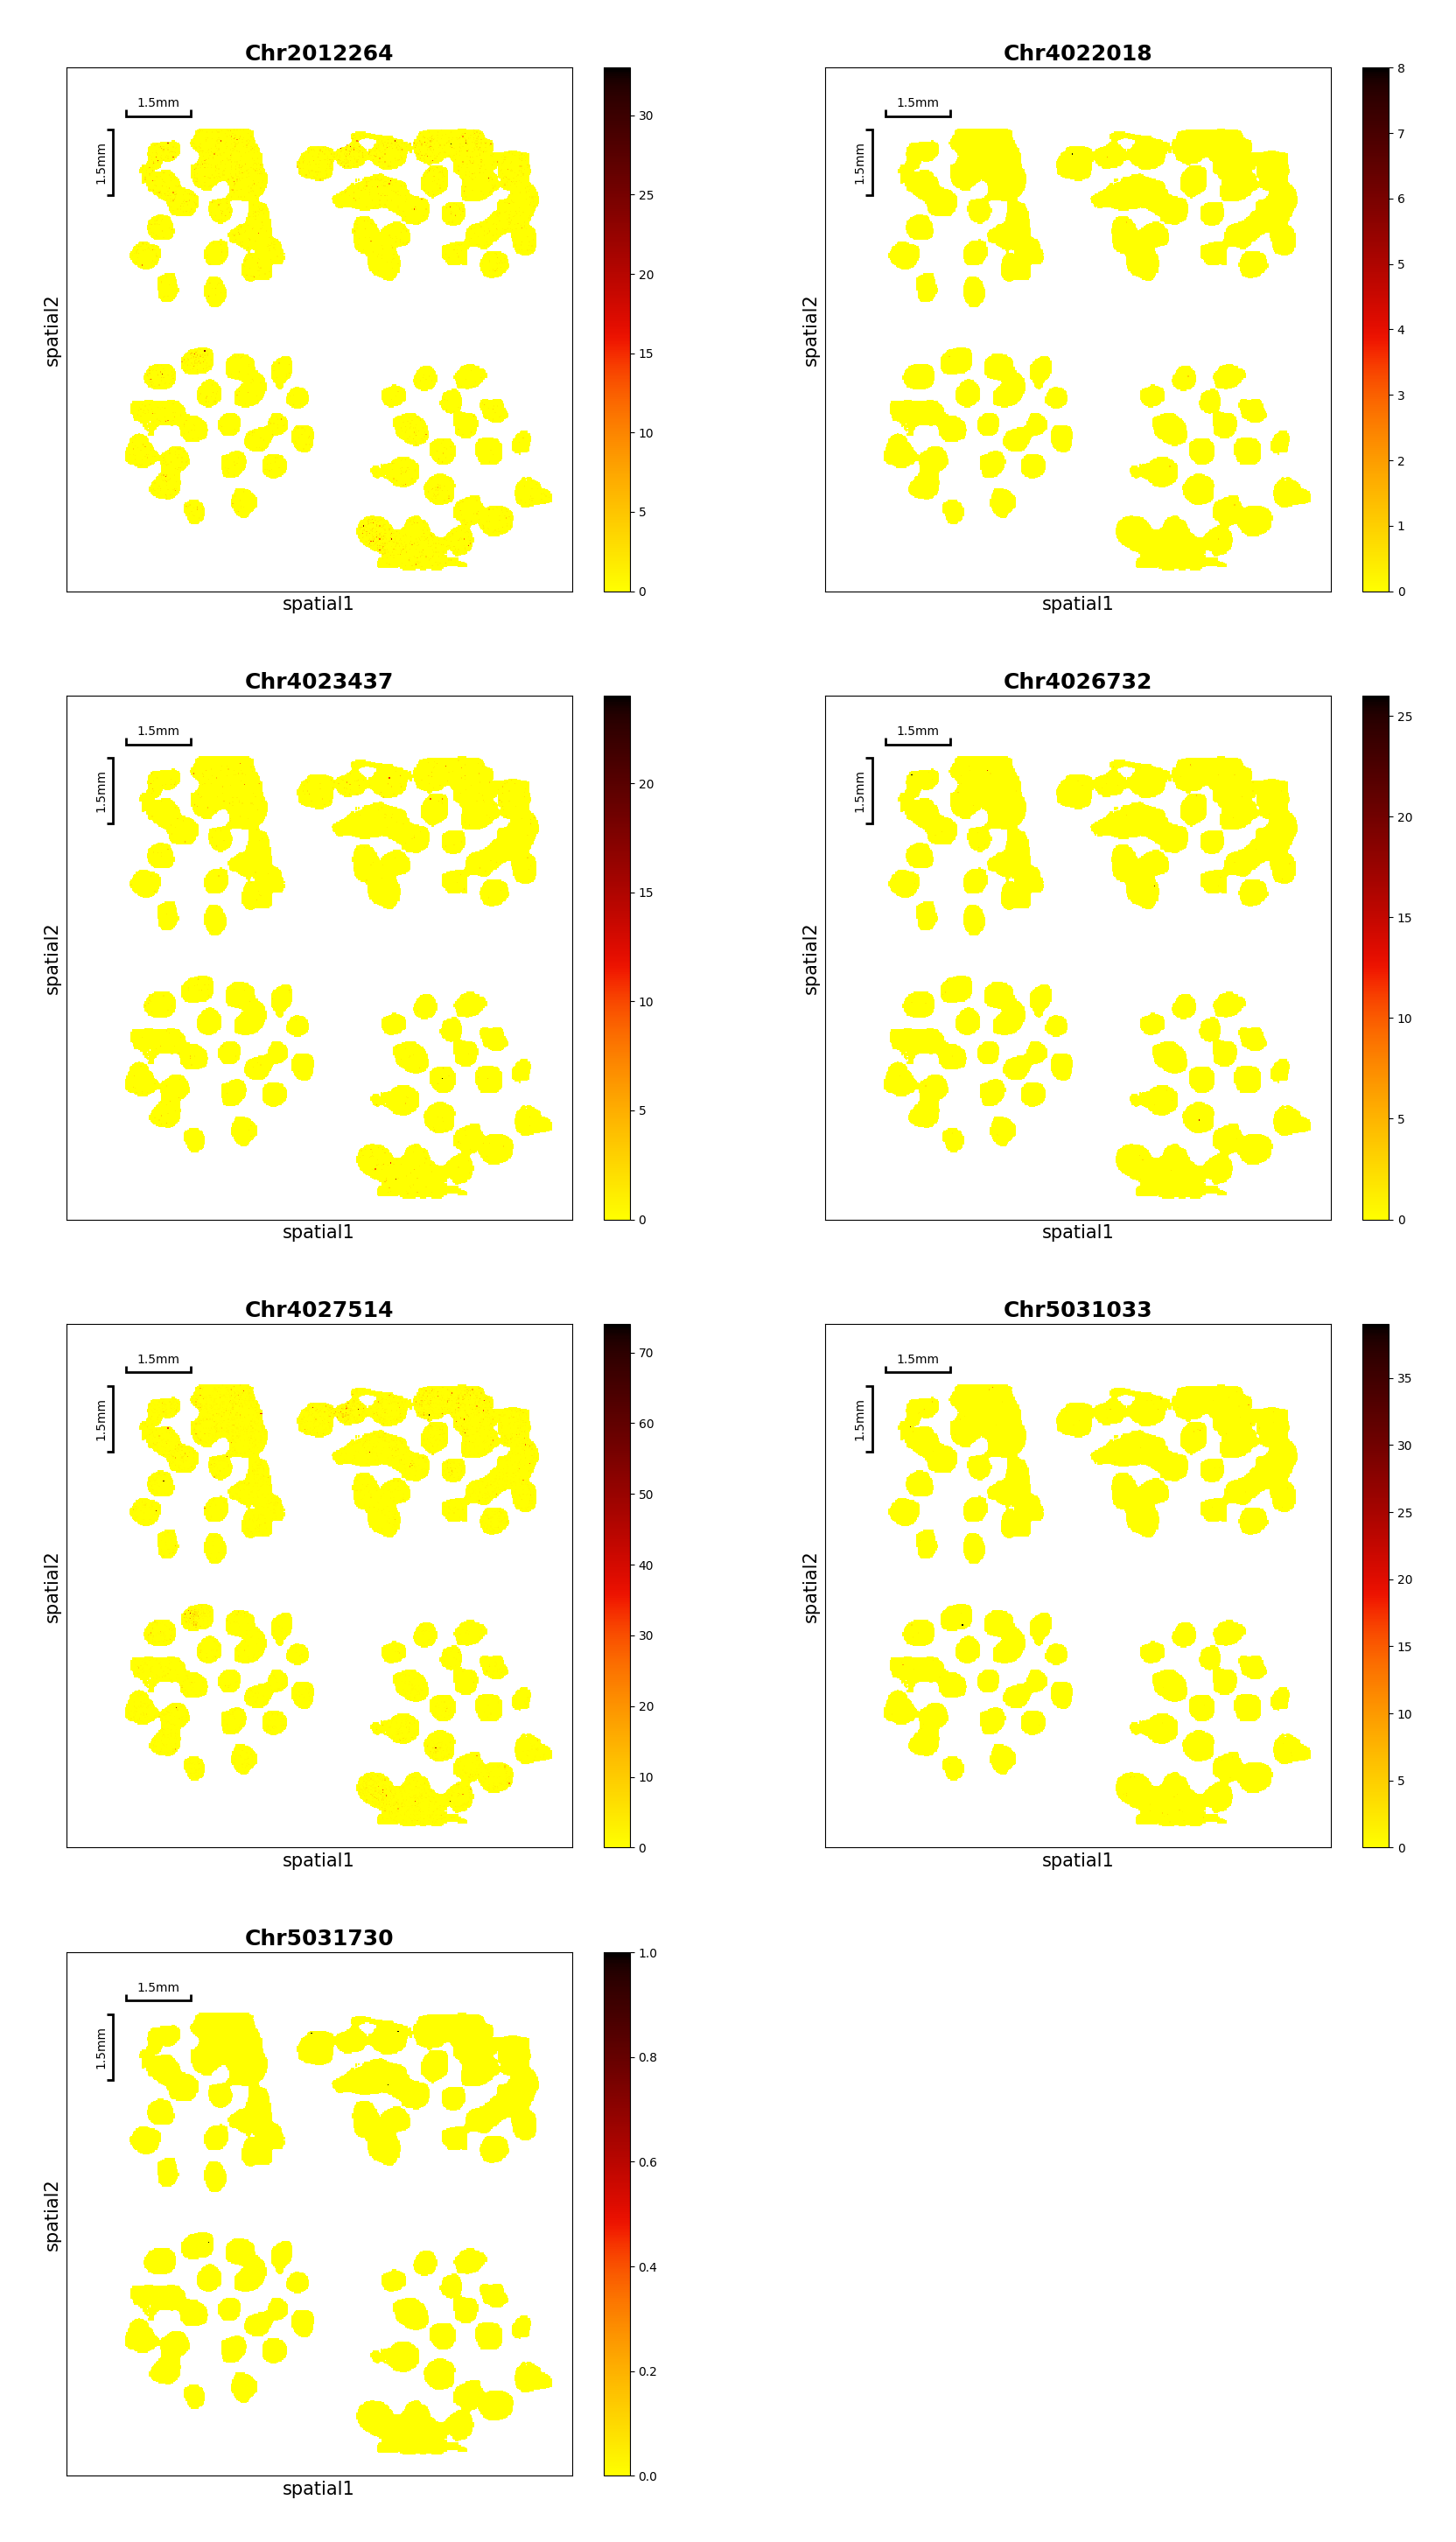

In [11]:
marker_list = ["Chr2012264","Chr4022018","Chr4023437","Chr4026732","Chr4027514","Chr5031033","Chr5031730"]

data.plt.spatial_scatter_by_gene(gene_name=marker_list)